In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf

In [3]:
# Daten laden
train_path = "data-science-competition-dscb-ss-26/train.csv"
test_path = "data-science-competition-dscb-ss-26/test.csv"
sample_submission_path = "data-science-competition-dscb-ss-26/sample_submission.csv"
output_path = "submission.csv"

train = pd.read_csv(train_path, parse_dates=["date"])
test = pd.read_csv(test_path, parse_dates=["date"])
sample_submission = pd.read_csv(sample_submission_path)

# Kalender Features
train["month"] = train["date"].dt.month
train["weekday"] = train["date"].dt.weekday
test["month"] = test["date"].dt.month
test["weekday"] = test["date"].dt.weekday

print("Train:", train.shape, " Test:", test.shape)

Train: (14319, 17)  Test: (2845, 16)


## EDA und konservative Datenbereinigung

> Vor der Modellierung prüfen wir Missingness, Duplikate, Zeitabdeckung und offensichtliche Plausibilitätsprobleme. Danach wenden wir nur vorsichtige Bereinigungen an, die keine Zielinformation aus der Zukunft verwenden.

In [4]:
# Datenbereinigung ohne aus Zukunft oder Testdaten gelernte Grenzwerte
def clean_air_quality_frame(df, *, is_train):
    df = df.copy()
    
    # Eindeutige IDs erzwingen und chronologisch sortieren
    df = df.drop_duplicates(subset="id", keep="first")
    df = df.sort_values(["station", "date"]).reset_index(drop=True)
    
    # Kategorische Werte vereinheitlichen
    if "wd" in df.columns:
        df["wd"] = df["wd"].astype(object)
        df["wd"] = df["wd"].where(pd.notna(df["wd"]), np.nan)
        mask = df["wd"].notna()
        df.loc[mask, "wd"] = df.loc[mask, "wd"].astype(str).str.strip().str.upper()
        df.loc[df["wd"].isin(["", "NAN", "NONE"]), "wd"] = np.nan
    
    # Physikalisch nicht plausible negative Werte kappen
    non_negative_cols = ["pm25", "pm10", "so2", "no2", "co", "o3", "rain", "wspm"]
    for col in non_negative_cols:
        if col in df.columns:
            df.loc[df[col] < 0, col] = np.nan
    
    if not is_train and "pm25" in df.columns:
        df = df.drop(columns="pm25")
    
    return df

train = clean_air_quality_frame(train, is_train=True)
test = clean_air_quality_frame(test, is_train=False)

print("Nach Bereinigung:")
print("Train:", train.shape, " Test:", test.shape)
print("Train Missing Values gesamt:", int(train.isna().sum().sum()))
print("Test Missing Values gesamt:", int(test.isna().sum().sum()))
print("Beispiel Windrichtungen:", sorted(train["wd"].dropna().unique())[:10])

Nach Bereinigung:
Train: (14319, 17)  Test: (2845, 16)
Train Missing Values gesamt: 1272
Test Missing Values gesamt: 95
Beispiel Windrichtungen: ['E', 'ENE', 'ESE', 'N', 'NE', 'NNE', 'NNW', 'NW', 'S', 'SE']


===== TRAIN =====
Shape: (14319, 17)
Zeitraum: 2013-03-01 bis 2016-06-30
Stationen: 12

Doppelte IDs: 0

Fehlende Werte in %:
co      4.41
o3      1.95
no2     1.63
so2     0.85
wd      0.03
temp    0.01
pres    0.01
dewp    0.01

Numerische Kennzahlen:
         mean     std     min      50%      max
pm25    78.84   66.91    3.00    60.27   567.42
pm10   105.17   72.12    4.83    89.62   580.00
so2     17.05   19.23    1.00     9.86   158.32
no2     50.31   27.42    2.00    45.83   201.29
co    1199.22  910.96  100.00   941.67  8117.39
o3      59.70   38.96    1.00    54.81   524.87
temp    13.81   10.60  -15.68    15.50    32.37
pres  1010.23   10.14  985.79  1009.78  1041.03
dewp     2.41   13.34  -33.02     2.79    27.62
rain     0.06    0.24    0.00     0.00     5.61
wspm     1.74    0.79    0.17     1.57     7.24

Zeitabdeckung pro Station:
              first_date  last_date  rows
station                                  
Aotizhongxin  2013-03-01 2016-06-30  1184
Changping     20

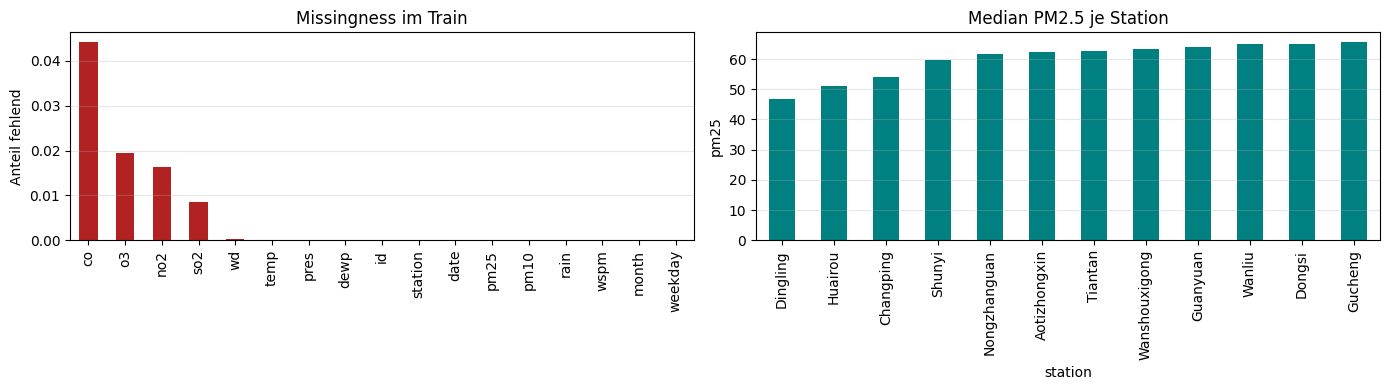

In [5]:
# EDA: Datenqualität, Missingness und zeitliche Abdeckung
numeric_cols_raw = ["pm25", "pm10", "so2", "no2", "co", "o3", "temp", "pres", "dewp", "rain", "wspm"]

def summarize_frame(df, name, target_col=None):
    print(f"===== {name} =====")
    print(f"Shape: {df.shape}")
    print(f"Zeitraum: {df['date'].min().date()} bis {df['date'].max().date()}")
    print(f"Stationen: {df['station'].nunique()}")
    print()
    
    dup_count = int(df['id'].duplicated().sum())
    print(f"Doppelte IDs: {dup_count}")
    
    missing = (df.isna().mean().sort_values(ascending=False) * 100).round(2)
    print("\nFehlende Werte in %:")
    print(missing[missing > 0].to_string() if (missing > 0).any() else "Keine fehlenden Werte")
    
    print("\nNumerische Kennzahlen:")
    cols = numeric_cols_raw if target_col is not None else [c for c in numeric_cols_raw if c in df.columns and c != 'pm25']
    print(df[cols].describe().round(2).T[["mean", "std", "min", "50%", "max"]].to_string())
    
    per_station = df.groupby('station').agg(first_date=('date', 'min'), last_date=('date', 'max'), rows=('id', 'size'))
    print("\nZeitabdeckung pro Station:")
    print(per_station.to_string())
    print()

summarize_frame(train, "TRAIN", target_col="pm25")
summarize_frame(test, "TEST")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
train.isna().mean().sort_values(ascending=False).plot(kind="bar", ax=axes[0], color="firebrick")
axes[0].set_title("Missingness im Train")
axes[0].set_ylabel("Anteil fehlend")
axes[0].grid(axis="y", alpha=0.3)

train.groupby("station")["pm25"].median().sort_values().plot(kind="bar", ax=axes[1], color="teal")
axes[1].set_title("Median PM2.5 je Station")
axes[1].set_ylabel("pm25")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
# Feature Registry und Hilfsfunktionen
categorical_features = ["station", "wd"]
base_numeric_features = [
    "pm10", "so2", "no2", "co", "o3",
    "temp", "pres", "dewp", "rain", "wspm",
    "month", "weekday",
]

def build_preprocessor(categorical_cols, numeric_cols):
    return ColumnTransformer(
        transformers=[
            ("categorical", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore")),
            ]), categorical_cols),
            ("numeric", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]), numeric_cols),
        ]
    )

def prepare_feature_set(name, train_df, test_df, categorical_cols, numeric_cols):
    feature_columns = categorical_cols + numeric_cols
    preprocessor = build_preprocessor(categorical_cols, numeric_cols)
    return {
        "name": name,
        "train": train_df.copy(),
        "test": test_df.copy(),
        "categorical_features": categorical_cols,
        "numeric_features": numeric_cols,
        "feature_columns": feature_columns,
        "preprocessor": preprocessor,
    }

# pm25-Lags sind fuer die mehrmonatige Testvorhersage nicht verfuegbar
# und werden deshalb bewusst nicht als Features angeboten.
feature_sets = {
    "baseline": prepare_feature_set(
        "baseline", train, test, categorical_features, base_numeric_features
    ),
}

active_feature_set_name = "baseline"
active_feature_set = feature_sets[active_feature_set_name]

print("Verfuegbare Feature-Sets:", list(feature_sets.keys()))
print("Aktives Feature-Set:", active_feature_set_name)
print("Feature-Anzahl:", len(active_feature_set["feature_columns"]))

Verfuegbare Feature-Sets: ['baseline']
Aktives Feature-Set: baseline
Feature-Anzahl: 14


In [7]:
# Validation Split auf dem aktiven Feature-Set
validation_start = pd.Timestamp("2016-01-01")
validation_end   = pd.Timestamp("2016-06-30")

active_train = active_feature_set["train"]
active_test = active_feature_set["test"]
feature_columns = active_feature_set["feature_columns"]
preprocessor = active_feature_set["preprocessor"]

fit_mask = active_train["date"] < validation_start
valid_mask = (active_train["date"] >= validation_start) & (active_train["date"] <= validation_end)

fit_dates = active_train.loc[fit_mask, "date"].reset_index(drop=True)
X_fit = active_train.loc[fit_mask, feature_columns].reset_index(drop=True)
y_fit = active_train.loc[fit_mask, "pm25"].reset_index(drop=True)
X_valid = active_train.loc[valid_mask, feature_columns].reset_index(drop=True)
y_valid = active_train.loc[valid_mask, "pm25"].reset_index(drop=True)

print("Aktives Feature-Set:", active_feature_set_name)
print("X_fit:", X_fit.shape, " X_valid:", X_valid.shape)

Aktives Feature-Set: baseline
X_fit: (12166, 14)  X_valid: (2153, 14)


In [8]:
# Modell-Bausteine und Suchraum
def make_pipeline(regressor, preprocessor_obj=None):
    return Pipeline([
        ("preprocessor", preprocessor if preprocessor_obj is None else preprocessor_obj),
        ("regressor", regressor),
    ])

model_registry = {
    "linear": {
        "factory": lambda: make_pipeline(LinearRegression()),
    },
    "ridge": {
        "factory": lambda: make_pipeline(Ridge()),
    },
    "lasso": {
        "factory": lambda: make_pipeline(Lasso(max_iter=10000)),
    },
    "elasticnet": {
        "factory": lambda: make_pipeline(ElasticNet(max_iter=10000)),
    },
}

regularized_search_space = [
    {"regressor": [Ridge()], "regressor__alpha": [0.01, 0.1, 1.0, 10.0]},
    {"regressor": [Lasso(max_iter=10000)], "regressor__alpha": [0.01, 0.1, 1.0, 10.0]},
    {
        "regressor": [ElasticNet(max_iter=10000)],
        "regressor__alpha": [0.01, 0.1, 1.0, 10.0],
        "regressor__l1_ratio": [0.2, 0.5, 0.8],
    },
]

def score_holdout(model, X_fit_df, y_fit_ser, X_valid_df, y_valid_ser):
    model.fit(X_fit_df, y_fit_ser)
    pred = model.predict(X_valid_df)
    mse = mean_squared_error(y_valid_ser, pred)
    return mse, pred

In [9]:
# Baseline auf dem aktiven Feature-Set
linear_model = model_registry["linear"]["factory"]()
linear_valid_mse, linear_valid_pred = score_holdout(
    linear_model, X_fit, y_fit, X_valid, y_valid
)
print(f"Linear Validation-MSE ({active_feature_set_name}): {linear_valid_mse:.3f}")

Linear Validation-MSE (baseline): 485.450


In [10]:
# === Schritt A: Walk-Forward-Validation ===
# Wir validieren das aktive Feature-Set mit einem frischen Modell auf mehreren chronologischen Folds.

train_sorted = active_feature_set["train"].sort_values("date").reset_index(drop=True)

folds = [
    ("Sommer 2015",   "2015-07-01", "2015-09-30"),
    ("Herbst 2015",   "2015-10-01", "2015-12-31"),
    ("Winter 2016",   "2016-01-01", "2016-03-31"),
    ("Frühjahr 2016", "2016-04-01", "2016-06-30"),
]

def walk_forward_eval(model_factory, train_df, folds, feature_cols):
    results = []
    for name, start, end in folds:
        start_ts, end_ts = pd.Timestamp(start), pd.Timestamp(end)
        fit_m = train_df["date"] < start_ts
        val_m = (train_df["date"] >= start_ts) & (train_df["date"] <= end_ts)

        if fit_m.sum() == 0 or val_m.sum() == 0:
            print(f"  [{name}] uebersprungen")
            continue

        Xf = train_df.loc[fit_m, feature_cols]
        yf = train_df.loc[fit_m, "pm25"]
        Xv = train_df.loc[val_m, feature_cols]
        yv = train_df.loc[val_m, "pm25"]

        model = model_factory()
        model.fit(Xf, yf)
        pred = model.predict(Xv)
        mse = mean_squared_error(yv, pred)
        results.append({"fold": name, "n_train": len(Xf), "n_valid": len(Xv), "mse": mse})
        print(f"  [{name:14s}]  n_train={len(Xf):5d}  n_valid={len(Xv):4d}  MSE={mse:8.2f}")

    df_res = pd.DataFrame(results)
    print(f"\n  Mittel MSE: {df_res['mse'].mean():.2f}   Std: {df_res['mse'].std():.2f}")
    return df_res

print(f"LinearRegression – Walk-Forward-Validation ({active_feature_set_name}):")
cv_results_linear = walk_forward_eval(
    model_registry["linear"]["factory"],
    train_sorted,
    folds,
    active_feature_set["feature_columns"],
)

LinearRegression – Walk-Forward-Validation (baseline):


  [Sommer 2015   ]  n_train= 9993  n_valid=1091  MSE=  185.18
  [Herbst 2015   ]  n_train=11084  n_valid=1082  MSE=  611.76


  [Winter 2016   ]  n_train=12166  n_valid=1088  MSE=  569.82


  [Frühjahr 2016 ]  n_train=13254  n_valid=1065  MSE=  390.74

  Mittel MSE: 439.38   Std: 194.69


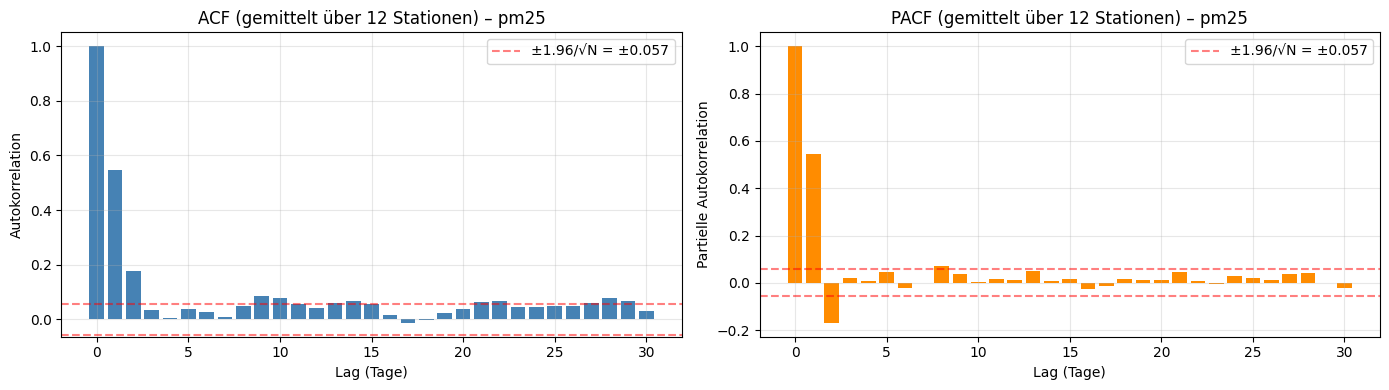


Konfidenzgrenze: ±0.057

Lag |   ACF   |  PACF   | PACF signifikant?
----+---------+---------+-------------------
  1 | +0.545  | +0.545  | JA
  2 | +0.178  | -0.169  | JA
  3 | +0.036  | +0.021  | —
  4 | +0.006  | +0.006  | —
  5 | +0.036  | +0.048  | —
  6 | +0.028  | -0.024  | —
  7 | +0.009  | -0.001  | —
  8 | +0.049  | +0.073  | JA
  9 | +0.086  | +0.037  | —
 10 | +0.077  | +0.003  | —
 11 | +0.058  | +0.018  | —
 12 | +0.040  | +0.013  | —
 13 | +0.060  | +0.049  | —
 14 | +0.067  | +0.009  | —
 15 | +0.056  | +0.014  | —
 16 | +0.017  | -0.028  | —
 17 | -0.013  | -0.013  | —
 18 | -0.001  | +0.018  | —
 19 | +0.022  | +0.013  | —
 20 | +0.036  | +0.013  | —
 21 | +0.063  | +0.046  | —
 22 | +0.066  | +0.008  | —
 23 | +0.046  | -0.006  | —
 24 | +0.046  | +0.028  | —
 25 | +0.050  | +0.023  | —
 26 | +0.048  | +0.011  | —
 27 | +0.061  | +0.037  | —
 28 | +0.079  | +0.040  | —
 29 | +0.069  | +0.000  | —
 30 | +0.032  | -0.023  | —


In [11]:
# === ACF / PACF Analyse zur Wahl der Lags ===
# Wir prüfen mehrere Stationen, mitteln die ACF/PACF-Werte.
# Erst pro Station rechnen, dann Mittelwert über Stationen plotten.

MAX_LAG = 30  # bis zu 30 Tage zurückschauen
target = "pm25"

stations = sorted(train["station"].unique())
acf_per_station = []
pacf_per_station = []

for st in stations:
    serie = (train[train["station"] == st]
             .sort_values("date")[target]
             .dropna()
             .values)
    if len(serie) <= MAX_LAG + 5:
        continue
    acf_vals = acf(serie, nlags=MAX_LAG, fft=False)
    # method="ywm" ist numerisch stabil für PACF
    pacf_vals = pacf(serie, nlags=MAX_LAG, method="ywm")
    acf_per_station.append(acf_vals)
    pacf_per_station.append(pacf_vals)

acf_mean = np.mean(acf_per_station, axis=0)
pacf_mean = np.mean(pacf_per_station, axis=0)

# Konfidenzband ~ 2 / sqrt(N), gemittelt über die Stationen-Längen
N = train.groupby("station").size().mean()
conf = 1.96 / np.sqrt(N)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(range(MAX_LAG + 1), acf_mean, color="steelblue")
axes[0].axhline(conf, color="red", linestyle="--", alpha=0.5, label=f"±1.96/√N = ±{conf:.3f}")
axes[0].axhline(-conf, color="red", linestyle="--", alpha=0.5)
axes[0].set_title("ACF (gemittelt über 12 Stationen) – pm25")
axes[0].set_xlabel("Lag (Tage)")
axes[0].set_ylabel("Autokorrelation")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].bar(range(MAX_LAG + 1), pacf_mean, color="darkorange")
axes[1].axhline(conf, color="red", linestyle="--", alpha=0.5, label=f"±1.96/√N = ±{conf:.3f}")
axes[1].axhline(-conf, color="red", linestyle="--", alpha=0.5)
axes[1].set_title("PACF (gemittelt über 12 Stationen) – pm25")
axes[1].set_xlabel("Lag (Tage)")
axes[1].set_ylabel("Partielle Autokorrelation")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Zahlen ausgeben – welche Lags sind signifikant?
print(f"\nKonfidenzgrenze: ±{conf:.3f}")
print("\nLag |   ACF   |  PACF   | PACF signifikant?")
print("----+---------+---------+-------------------")
for k in range(1, MAX_LAG + 1):
    sig = "JA" if abs(pacf_mean[k]) > conf else "—"
    print(f"{k:3d} | {acf_mean[k]:+.3f}  | {pacf_mean[k]:+.3f}  | {sig}")

In [12]:
# === Schritt B: Inspektion der fuer die Submission verfuegbaren Features ===
print("Aktives Feature-Set:", active_feature_set_name)
print("Ziel-Lag-Features: keine (pm25 ist im Testzeitraum unbekannt)")
print(f"Feature-Anzahl gesamt: {len(active_feature_set['feature_columns'])}")
print("Verwendete Features:", active_feature_set["feature_columns"])

Aktives Feature-Set: baseline
Ziel-Lag-Features: keine (pm25 ist im Testzeitraum unbekannt)
Feature-Anzahl gesamt: 14
Verwendete Features: ['station', 'wd', 'pm10', 'so2', 'no2', 'co', 'o3', 'temp', 'pres', 'dewp', 'rain', 'wspm', 'month', 'weekday']


In [13]:
# Regularisierte Modelle werden innerhalb des Fit-Zeitraums getunt.
# Der spaetere Holdout 2016 bleibt bis zur finalen Modellauswahl unangetastet.
regularized_linear_pipeline = make_pipeline(Ridge())

In [14]:
# Regularisierte Suche mit explizit chronologischen Folds auf dem Fit-Zeitraum
tuning_periods = [
    ("Sommer 2014", "2014-07-01", "2014-09-30"),
    ("Winter 2015", "2015-01-01", "2015-03-31"),
    ("Herbst 2015", "2015-10-01", "2015-12-31"),
]
temporal_cv = []
for fold_name, start, end in tuning_periods:
    start_ts, end_ts = pd.Timestamp(start), pd.Timestamp(end)
    train_idx = np.flatnonzero((fit_dates < start_ts).to_numpy())
    valid_idx = np.flatnonzero(((fit_dates >= start_ts) & (fit_dates <= end_ts)).to_numpy())
    temporal_cv.append((train_idx, valid_idx))
    print(f"{fold_name}: Train bis {start_ts.date()}, Validation {start_ts.date()} bis {end_ts.date()}")

regularized_linear_search = GridSearchCV(
    estimator=regularized_linear_pipeline,
    param_grid=regularized_search_space,
    cv=temporal_cv,
    scoring="neg_mean_squared_error",
    n_jobs=1,
)
regularized_linear_search.fit(X_fit, y_fit)
print("Beste Tuning-Parameter:", regularized_linear_search.best_params_)
print(f"Beste zeitliche Tuning-MSE: {-regularized_linear_search.best_score_:.3f}")

Sommer 2014: Train bis 2014-07-01, Validation 2014-07-01 bis 2014-09-30
Winter 2015: Train bis 2015-01-01, Validation 2015-01-01 bis 2015-03-31
Herbst 2015: Train bis 2015-10-01, Validation 2015-10-01 bis 2015-12-31


Beste Tuning-Parameter: {'regressor': Lasso(max_iter=10000), 'regressor__alpha': 0.1}
Beste zeitliche Tuning-MSE: 605.357


In [15]:
regularized_linear_model = regularized_linear_search.best_estimator_
regularized_linear_valid_mse, regularized_linear_valid_pred = score_holdout(
    regularized_linear_model, X_fit, y_fit, X_valid, y_valid
)
print(f"Regularisiert Validation-MSE ({active_feature_set_name}): {regularized_linear_valid_mse:.3f}")

X_train_full = active_feature_set["train"][active_feature_set["feature_columns"]]
y_train_full = active_feature_set["train"]["pm25"]
X_test = active_feature_set["test"][active_feature_set["feature_columns"]]

Regularisiert Validation-MSE (baseline): 475.884


In [16]:
# Finale Auswahl auf dem zeitlich spaeteren Holdout
if regularized_linear_valid_mse < linear_valid_mse:
    best_model_label = "regularized_search_best"
    best_model = regularized_linear_model
else:
    best_model_label = "linear"
    best_model = linear_model

print(f"Bestes Modell: {best_model_label}")
best_model.fit(X_train_full, y_train_full)
test_pred = best_model.predict(X_test)

Bestes Modell: regularized_search_best


In [17]:
# Submission erzeugen + speichern
predictions_by_id = pd.Series(test_pred, index=test["id"])

submission = sample_submission[["id"]].copy()
raw_pred = predictions_by_id.reindex(submission["id"]).to_numpy()

# Clipping: PM2.5 kann nicht negativ sein
submission["pm25"] = np.round(np.clip(raw_pred, a_min=0.0, a_max=None), 3)

submission.to_csv(output_path, index=False)
print("Submission geschrieben:", output_path)
print("Shape:", submission.shape)
submission.head()

Submission geschrieben: submission.csv
Shape: (2845, 2)


,id,pm25
0,Aotizhongxin_2016-07-01,0.000
1,Changping_2016-07-01,0.000
2,Dingling_2016-07-01,0.000
3,Dongsi_2016-07-01,3.224
4,Guanyuan_2016-07-01,3.298
